Ensemble de ville avec distances

trouver le plus petit chemin qui relie toutes les villes sans passer par une ville plus d'une fois.



3 heuristique 

plus proche voisin

k-opt 

algorithme génétique

1 individu = une solution possible (une parcours de villes) , genere 100 parcours differents , une fonction d'evaluation (le cout du parcours) , selectionne les meilleurs parcours , croisement (melange de 2 parcours pour en faire un nouveau) , mutation (changer l'ordre de 2 villes dans le parcours)

à la fin afficher le parcours le plus court trouvé et sa distance totale.

# TSP (Travelling Salesman Problem)

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import time

from pprint import pprint

from tsp.io import load_cities, process_pays_travel
from tsp.structure import Pays
from tsp.solvers import LocalSearch, KNN 

Distance totale partant de Alger : 89.65243749735936
Distance totale partant de Oran : 91.61155818127078
Distance totale partant de Constantine : 86.50474542473842
Distance totale partant de Annaba : 89.49718314888904
Distance totale partant de Blida : 89.72895275047816
Distance totale partant de Batna : 89.58317848260623
Distance totale partant de Sétif : 85.71026961089458
Distance totale partant de Tlemcen : 89.4649927343156
Distance totale partant de Sidi Bel Abbès : 91.37250206373973
Distance totale partant de Biskra : 89.22368647215109
Distance totale partant de Djelfa : 86.74088742708408
Distance totale partant de Béjaïa : 96.95382798851784
Distance totale partant de Skikda : 86.35213302313464
Distance totale partant de Tébessa : 87.33744086145855
Distance totale partant de M'Sila : 97.37737032308884
Distance totale partant de Ouargla : 89.77657169901934
Distance totale partant de Tiaret : 88.09253327822371
Distance totale partant de Chlef : 88.57998968127526
Distance totale part

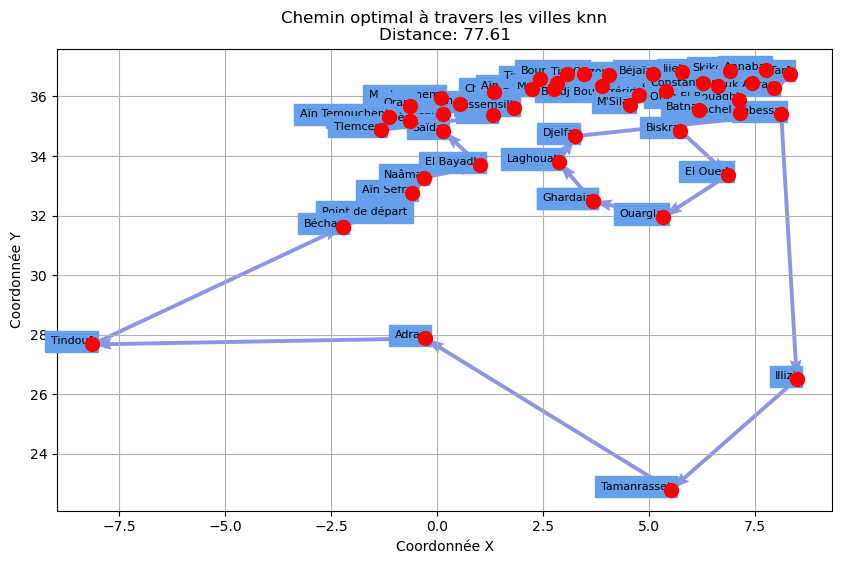

In [2]:
liste_dz = load_cities("../data/dz-50.csv", separator=";")


algerie50 = Pays("Algérie", liste_dz)
algerie50.get_matrix_with_labels()
algerie50.compute_all_paths()
algerie50.print_distance_from_each_city()
algerie50.get_optimal_path()
algerie50.print_distance_from_each_city()
algerie50.plot_path_knn()

In [3]:
pprint(algerie50.__dict__) # affiche les attributs de l'objet algerie50

{'best_path_knn': ['Béchar',
                   'Aïn Séfra',
                   'Naâma',
                   'El Bayadh',
                   'Saïda',
                   'Mascara',
                   'Relizane',
                   'Mostaganem',
                   'Oran',
                   'Sidi Bel Abbès',
                   'Aïn Temouchent',
                   'Tlemcen',
                   'Tiaret',
                   'Tissemsilt',
                   'Chlef',
                   'Aïn Defla',
                   'Tipaza',
                   'Blida',
                   'Médéa',
                   'Alger',
                   'Boumerdès',
                   'Tizi Ouzou',
                   'Bouira',
                   'Bordj Bou Arréridj',
                   "M'Sila",
                   'Sétif',
                   'Béjaïa',
                   'Jijel',
                   'Mila',
                   'Constantine',
                   'Skikda',
                   'Guelma',
                   'Sou

# Approche k-opt

In [ ]:
import time

# 1. Charger tes données (utilise ton fichier de 50 villes pour un bon test)
print("--- Chargement des données ---")
liste_villes = load_cities("../data/dz-50.csv", separator=";")
algerie50 = Pays("Algerie50", liste_villes)

# 2. Calculer les chemins de base avec KNN
print("\n--- Étape 1 : KNN ---")
algerie50.compute_all_paths()
start, path_knn, dist_knn = algerie50.knn.get_optimal_path()
print(f"Distance initiale (KNN) : {dist_knn:.2f}")

# 3. Améliorer avec 2-opt
print("\n--- Étape 2 : 2-opt ---")
path_2opt, dist_2opt = algerie50.two_opt.two_opt(path_knn[:-1])
print(f"Distance après 2-opt : {dist_2opt:.2f}")

# 4. Tester ton nouveau 3-opt et le chronométrer
print("\n--- Étape 3 : 3-opt ---")
start_time = time.time() # On lance le chrono
path_3opt, dist_3opt = algerie50.two_opt.three_opt(path_2opt)
end_time = time.time()   # On arrête le chrono

# 5. Afficher le bilan
print(f"Distance après 3-opt : {dist_3opt:.2f}")
print(f"Temps d'exécution du 3-opt : {end_time - start_time:.4f} secondes")

amelioration = dist_2opt - dist_3opt

if amelioration > 0:
    pourcentage = (amelioration / dist_2opt) * 100
    print(f"\nLe 3-opt a encore réduit la distance de {amelioration:.2f} ({pourcentage:.2f}%) !")
elif amelioration == 0:
    print("\nL'algorithme a tourné normalement. Le 2-opt avait déjà trouvé un excellent minimum local pour ce jeu de données.")
else:
    print("\nLa distance a augmenté, il y a une erreur dans la reconstruction.")

--- Chargement des données ---

--- Étape 1 : KNN ---
Distance initiale (KNN) : 77.61

--- Étape 2 : 2-opt ---
Distance après 2-opt : 74.43

--- Étape 3 : 3-opt ---
Distance après 3-opt : 71.93
Temps d'exécution du 3-opt : 0.2262 secondes

✅ SUCCÈS : Le 3-opt a encore réduit la distance de 2.50 (3.36%) !
